<sub>Felix Becker, Lars Gabriel University of Greifswald, Germany</sub>
# Solutions to Exercise Set 1 - 3 - Preparing Tabular Data

The potential of machine learning ultimatively comes from pattern detection in large amounts of data. However, before we can train a model and make predictions, we have to:
 - Analyse the raw data (which filetypes, how is the data organized?)
 - Read data file(s) into memory
 - Make statistical analyses (e.g. plots)  
 - Manipulate the data (reshape and mathematical operations), remove, add or combine features
 
## Raw data

Inspect the file *bikes-summerdays-full.csv*. How many datapoints and attributes are there? What delimiter is used? Has the file one or more header rows? Are there missing values?

*Tip: Double clicking the file in jupyter opens a CSVTable view. You can also open the file as raw text by right clicking $\rightarrow$ Open With $\rightarrow$ Editor.*  
Yet another alternative is to use `less` and `wc` on the command line in the terminal.

## Read the file



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In the cell below, read the data file as a pandas dataframe called ``df``. Take care to handle the header line of the file correctly and use the right delimiter/separator.

In [2]:
df = pd.read_csv("../../bikes-summerdays-full.csv", sep = ";") #YOUR TASK: choose a correct separator with the "sep" argument

Print the following things:
- What is the shape of the dataframe?
- What are the datatypes of the columns "season" and "temp"?
- What is the maximum and minimum temperature?

Remember that `df` is a [pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) and that you can use class member functions like [dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html) or on a column [pandas.Series.max](https://pandas.pydata.org/docs/reference/api/pandas.Series.max.html#pandas.Series.max) to solve the task. Alternatively, you could also apply numpy functions to numeric columns after applying `.to_numpy()`. Useful functions are `np.min` and `np.max`.

In [3]:
## YOUR CODE HERE
## play around with the dataframe and complete the tasks above
print(df.shape)
print(df.dtypes)
# loop over numerical columns
for col in df.columns:
    if df[col].dtype == "int64" or df[col].dtype == "float64":
        print(col, "mean:", df[col].mean().round(2), "min:", df[col].min(), "max:", df[col].max())


(10886, 12)
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object
season mean: 2.51 min: 1 max: 4
holiday mean: 0.03 min: 0 max: 1
workingday mean: 0.68 min: 0 max: 1
weather mean: 1.42 min: 1 max: 4
temp mean: 20.23 min: 0.82 max: 41.0
atemp mean: 23.66 min: 0.76 max: 45.455
humidity mean: 61.89 min: 0 max: 100
windspeed mean: 12.8 min: 0.0 max: 56.9969
casual mean: 36.02 min: 0 max: 367
registered mean: 155.55 min: 0 max: 886
count mean: 191.57 min: 1 max: 977


The dataset contains dates that are rather useless if stored as strings:

In [4]:
df["datetime"]

0        2011-01-01 00:00:00
1        2011-01-01 01:00:00
2        2011-01-01 02:00:00
3        2011-01-01 03:00:00
4        2011-01-01 04:00:00
                ...         
10881    2012-12-19 19:00:00
10882    2012-12-19 20:00:00
10883    2012-12-19 21:00:00
10884    2012-12-19 22:00:00
10885    2012-12-19 23:00:00
Name: datetime, Length: 10886, dtype: object

The following cell will convert *datetime* to a proper time format that allows the extraction of hours, days and month. If the following cell prints an error message, go back and make sure you chose the correct separator character.

In [5]:
df["datetime"] = pd.DatetimeIndex(df["datetime"])
df["hour"] = [t.hour for t in df["datetime"]]
df["dayofweek"] = [t.dayofweek for t in df["datetime"]]
df["month"] = [t.month for t in df["datetime"]]

## Warm up: Simple statistical analyses

The original data came with a [description for each data column](https://www.kaggle.com/datasets/marklvl/bike-sharing-dataset). Lets assume we don't have this description and want to find out what the encoding 1,2,3,4 for "season" means. 

- Print (a subset of) the values from the "season" column
- Use the helper function below to create boxplots for the temperatures of the 4 seasons and make a guess which number corresponds to which season.

*Tips (assuming X,Y are vectors of the same size):*
- *``X == i`` returns a boolean vector that has "true" on each position that matches i.*
- *use ``Y[X == i]`` (boolean mask) to retrieve subsets*

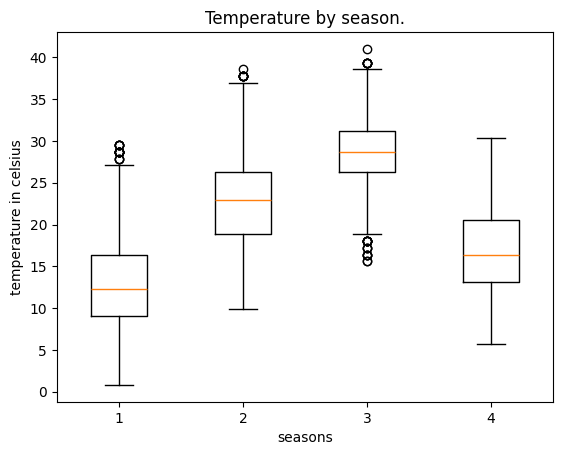

In [6]:
# expects data to be a list of length 4, where entry i is a np.array of temperatures for season i
def boxplots(data):
    _, ax = plt.subplots()
    ax.set_title("Temperature by season.")
    ax.set_xlabel("seasons")
    ax.set_ylabel("temperature in celsius")
    ax.boxplot(data)
    
# YOUR CODE STARTS
data = [df["temp"][df["season"] == s] for s in range(1,5)]
# YOUR CODE ENDS

boxplots(data)

## Feature engineering: Create a datamatrix

Most of the time, the raw data that we read from a file is not sufficient to be directly fed to a ML model. Usually we do:
- Standardize continuous variables (in some form).
- Normalize numerical integer features to roughly comparable ranges, e.g. [0,1] or [-1,1].
- One-hot represent categorical variables.
- Apply other transformations, for example
    - we could guess that both for very low and very high temperatures fewer bikes are rented so that the square of the temperature might be useful or
    - the body mass index which relates weight to the square of the height

* Not normalized/standardized input data can result in unsuccessful or very slow training runs.
The point about feature transformation becomes less important when applying deep learning to large data as in principal non-linear models could learn these transformations on their own.*

Create a `np.matrix` $X$ of datatype float with the following columns:
- workingday, holiday
- normalized: windspeed, humidity, temp, atemp
- squares of temp and atemp
- one hot represented (!) weather and season
- hour, dayofweek, month (normalized to (0,1], e.g. lunch time at 12am should map to 0.5)

A **one hot representation** for example of the four seasons would map season $3$ to the vector $[0,0,1,0]$, which then make up 4 columns in the data matrix.

*Tip: Use the functions `to_one_hot` and `normalize`*

In [7]:
m = df.shape[0] #number of datapoints
n = 19 #number of attributes 19

X = np.zeros((m, n)) # initialize with all zeros

#assumes that classes is a vector of length m with elements in range 0,1,...,num_classes-1
#returns a matrix of shape (m, num_classes)
def to_one_hot(classes, num_classes):
    return np.eye(num_classes)[classes]

#assumes that X is a vector, returns a normalized X
def normalize(X):
    return (X - np.mean(X)) / np.std(X)

#example:
X[:,0] = df["workingday"]

# YOUR CODE STARTS
# add the remaining columns X[:,1], X[:,2], ...
X[:,1] = df["holiday"]
X[:,2] = normalize(df["windspeed"])
X[:,3] = normalize(df["humidity"])
X[:,4] = normalize(df["temp"])
X[:,5] = normalize(df["atemp"])
X[:,6] = X[:,4]**2
X[:,7] = X[:,5]**2
X[:,8:12] = to_one_hot(df["weather"]-1, 4)
X[:,12:16] = to_one_hot(df["season"]-1, 4)
X[:,16] = df["hour"] / 24
X[:,17] = df["dayofweek"] / 7
X[:,18] = df["month"] / 12
# YOUR CODE ENDS

X[0:2,:] # show first two rows of X

array([[ 0.        ,  0.        , -1.56775367,  0.99321305, -1.33366069,
        -1.09273697,  1.77865084,  1.19407408,  1.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.71428571,  0.08333333],
       [ 0.        ,  0.        , -1.56775367,  0.94124921, -1.43890721,
        -1.18242083,  2.07045395,  1.39811902,  1.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.04166667,  0.71428571,  0.08333333]])

In [8]:
# save X and y to (binary) files as we will later use them in another notebook
np.save("X", X)
y = df["count"].to_numpy()
np.save("y", y)

We will use $X,y$ later to train a neural network.

In Python *numpy* is usually used to transfer numeric data between frameworks e.g. it allows communication of *pandas* and *tensorflow*.

## Fit a multivariate regression model

Fitting a linear regression model on our prepared data using high-level keras is very easy. Read and execute the code below and see it happening.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# Convert X and y to torch tensors
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float().view(-1, 1)

# Create a TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)

# Use random_split to create an 80/20 train-validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders with batch_size = 32; let DataLoader handle the shuffling for training
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Define the model: a single linear layer with the appropriate input dimension
model = nn.Linear(X.shape[1], 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

num_epochs = 20
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    avg_train_loss = running_loss / train_size
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = running_val_loss / val_size
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

print(model)

Epoch 1/20 - Loss: 44688.2816 - Val Loss: 29268.4459
Epoch 2/20 - Loss: 27391.1547 - Val Loss: 24247.7746
Epoch 3/20 - Loss: 24516.7749 - Val Loss: 22907.5828
Epoch 4/20 - Loss: 23413.8129 - Val Loss: 22382.2662
Epoch 5/20 - Loss: 22900.5573 - Val Loss: 22166.9906
Epoch 6/20 - Loss: 22623.8565 - Val Loss: 22023.7217
Epoch 7/20 - Loss: 22438.7490 - Val Loss: 21929.9532
Epoch 8/20 - Loss: 22296.2512 - Val Loss: 21814.5426
Epoch 9/20 - Loss: 22173.6118 - Val Loss: 21709.1915
Epoch 10/20 - Loss: 22066.8282 - Val Loss: 21615.9895
Epoch 11/20 - Loss: 21964.2399 - Val Loss: 21533.5939
Epoch 12/20 - Loss: 21900.8495 - Val Loss: 21466.1717
Epoch 13/20 - Loss: 21818.1095 - Val Loss: 21451.1433
Epoch 14/20 - Loss: 21782.4206 - Val Loss: 21351.4338
Epoch 15/20 - Loss: 21714.2093 - Val Loss: 21297.5281
Epoch 16/20 - Loss: 21663.8482 - Val Loss: 21274.2132
Epoch 17/20 - Loss: 21648.3686 - Val Loss: 21239.8293
Epoch 18/20 - Loss: 21617.6090 - Val Loss: 21209.3341
Epoch 19/20 - Loss: 21591.1909 - Val 

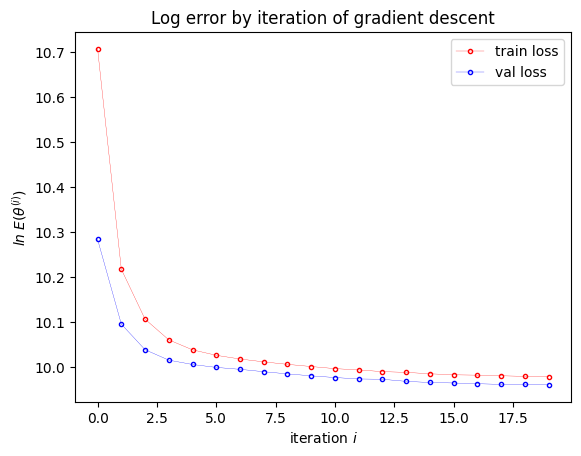

In [10]:
def plot_error(err, label, col="red"):
    ''' Plot error over time'''
    plt.plot(np.log(err), 'o-', color=col, linewidth=.2, markersize=3, mfc='none', label=label)
    plt.title("Log error by iteration of gradient descent")
    plt.xlabel('iteration '+r'$i$')
    plt.ylabel(r'$ln \;E(\theta^{(i)})$');
    
plt.subplots()
plot_error(train_losses, label="train loss")
plot_error(val_losses, col="blue", label="val loss")
plt.legend();

Tipps:
  - Compute also a baseline accuracy of a trivial method, e.g. one that always predicts the average bike count.
  - Repeat the training, as the results are random. Is the validation loss always much larger than the training loss?
  - If the results are unexpectedly poor, e.g. close to the baseline, check your normalization.
